Epoch  200 | Loss: 3.8240 | w: 3.5712 | b: 1.6400
Epoch  400 | Loss: 3.7460 | w: 3.5145 | b: 2.0123
Epoch  600 | Loss: 3.7366 | w: 3.4949 | b: 2.1416
Epoch  800 | Loss: 3.7355 | w: 3.4880 | b: 2.1865
Epoch 1000 | Loss: 3.7353 | w: 3.4856 | b: 2.2021

===== 训练结果 =====
拟合参数:  w = 3.4856,  b = 2.2021
真实参数:  w = 3.5,  b = 2.0


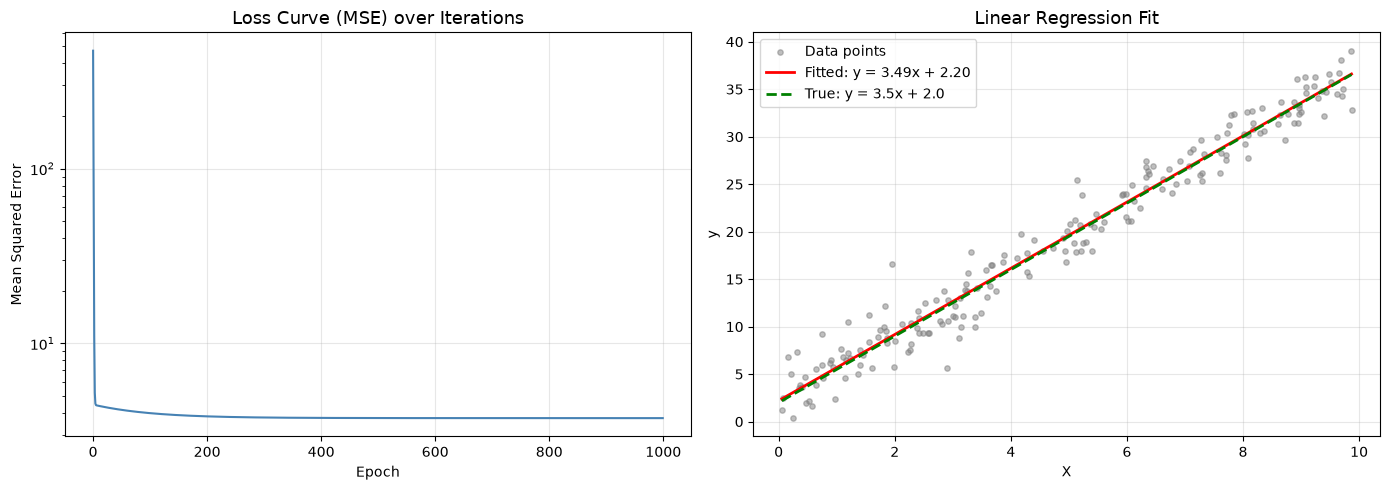

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 生成模拟数据
# ============================================================
np.random.seed(42)

n_samples = 200
X = np.random.rand(n_samples) * 10          # 特征 x ∈ [0, 10)
true_w, true_b = 3.5, 2.0                   # 真实的 w 和 b
noise = np.random.randn(n_samples) * 2      # 高斯噪声
y = true_w * X + true_b + noise             # y = wx + b + noise

# ============================================================
# 2. 梯度下降法求解
# ============================================================
def gradient_descent(X, y, lr=0.01, epochs=1000):
    """
    用梯度下降法求解线性回归  y = w*x + b

    参数:
        X      : 一维数组, 特征
        y      : 一维数组, 标签
        lr     : 学习率
        epochs : 迭代次数

    返回:
        w, b, loss_history
    """
    n = len(X)
    w = 0.0  # 权重初始化
    b = 0.0  # 偏置初始化

    loss_history = []

    for epoch in range(epochs):
        # ---------- 前向传播 ----------
        y_pred = w * X + b

        # ---------- 计算损失 (MSE) ----------
        error = y_pred - y
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        # ---------- 计算梯度 ----------
        # 对 w 的偏导: (2/n) * Σ (y_pred - y) * X
        dw = (2 / n) * np.sum(error * X)
        # 对 b 的偏导: (2/n) * Σ (y_pred - y)
        db = (2 / n) * np.sum(error)

        # ---------- 更新参数 ----------
        w -= lr * dw
        b -= lr * db

        # 可选：每隔一定轮次打印进度
        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch+1:>4d} | Loss: {loss:.4f} | w: {w:.4f} | b: {b:.4f}")

    return w, b, loss_history

# 运行训练
learning_rate = 0.01
num_epochs = 1000
w, b, loss_history = gradient_descent(X, y, lr=learning_rate, epochs=num_epochs)

print(f"\n===== 训练结果 =====")
print(f"拟合参数:  w = {w:.4f},  b = {b:.4f}")
print(f"真实参数:  w = {true_w},  b = {true_b}")

# ============================================================
# 3. 可视化
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 左图：损失下降曲线 ----------
axes[0].plot(loss_history, color='steelblue', linewidth=1.5)
axes[0].set_title("Loss Curve (MSE) over Iterations", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")
axes[0].set_yscale("log")  # 对数坐标更容易观察收敛
axes[0].grid(True, alpha=0.3)

# ---------- 右图：数据点 & 拟合直线 ----------
axes[1].scatter(X, y, s=15, alpha=0.5, label="Data points", color='gray')
x_line = np.linspace(X.min(), X.max(), 100)
axes[1].plot(x_line, w * x_line + b, color='red', linewidth=2,
             label=f"Fitted: y = {w:.2f}x + {b:.2f}")
axes[1].plot(x_line, true_w * x_line + true_b, color='green',
             linewidth=2, linestyle='--',
             label=f"True: y = {true_w}x + {true_b}")
axes[1].set_title("Linear Regression Fit", fontsize=13)
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("linear_regression_result.png", dpi=150)
plt.show()

c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to

==================== 实验结果汇总表 ====================
Penalty       C  Train_Acc  Test_Acc  Non_Zero_Features
     L1   0.001   0.371859  0.374269                  0
     L1   0.010   0.932161  0.900585                  2
     L1   0.100   0.979899  0.959064                  7
     L1   1.000   0.987437  0.976608                 14
     L1  10.000   0.994975  0.959064                 22
     L1 100.000   1.000000  0.953216                 26
     L2   0.001   0.947236  0.947368                 30
     L2   0.010   0.974874  0.959064                 30
     L2   0.100   0.984925  0.982456                 30
     L2   1.000   0.987437  0.988304                 30
     L2  10.000   0.989950  0.982456                 30
     L2 100.000   0.997487  0.953216                 30


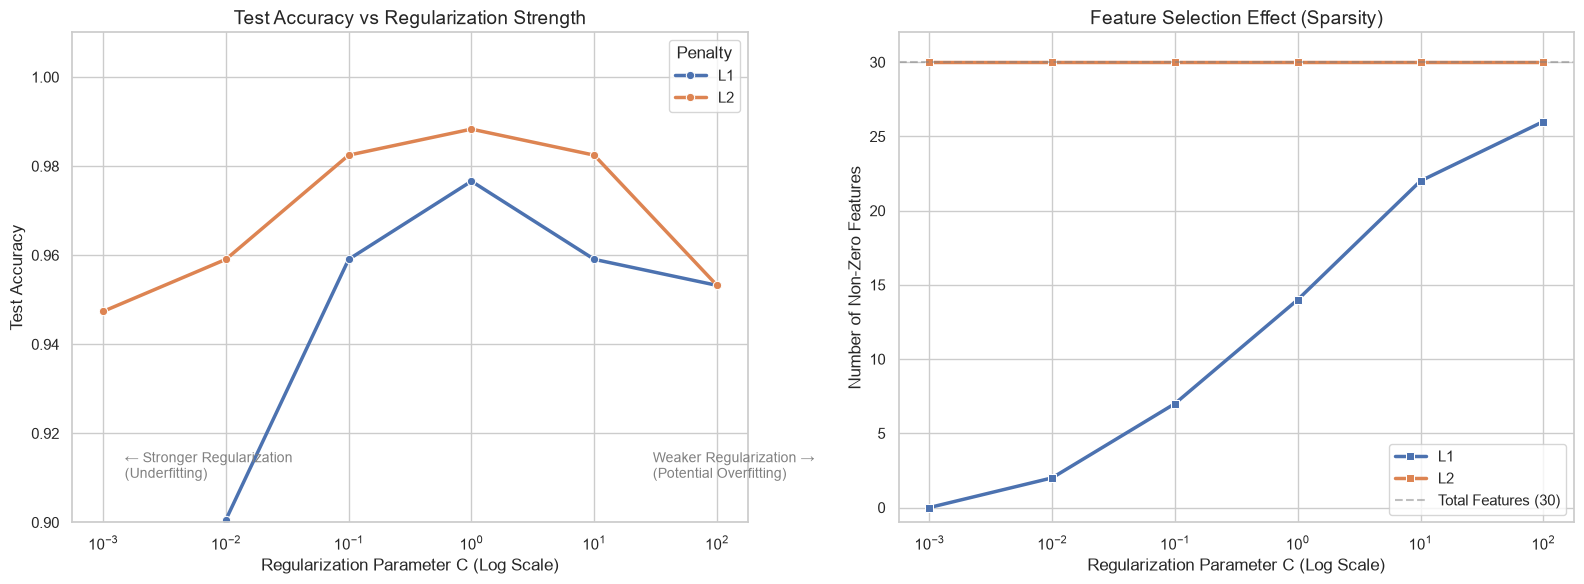



==================== L1 特征选择细节 (C=0.01) ====================
被 L1 正则化压缩为 0 的特征（被剔除）：
['mean perimeter', 'mean area', 'mean radius', 'mean texture', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'mean smoothness', 'mean compactness', 'area error', 'perimeter error', 'smoothness error', 'compactness error', 'symmetry error', 'fractal dimension error', 'concavity error', 'concave points error', 'worst texture', 'worst radius', 'worst smoothness', 'worst area', 'worst compactness', 'worst concavity', 'worst symmetry', 'worst fractal dimension']

权重绝对值最大的前 5 个核心特征：
             Feature    Weight
worst concave points -0.410572
     worst perimeter -0.224303
      mean perimeter  0.000000
           mean area  0.000000
         mean radius  0.000000


c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 设置绘图风格
sns.set_theme(style="whitegrid")

# ============================================================
# 1. 数据加载与预处理
# ============================================================
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# 划分训练集和测试集 (70% 训练, 30% 测试)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 【关键】特征标准化：正则化对特征尺度非常敏感，必须做标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 2. 实验设计：遍历不同的正则化类型和强度
# ============================================================
# C 是正则化强度的倒数：C 越小，正则化越强；C 越大，正则化越弱（越容易过拟合）
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
penalties = ['l1', 'l2']

results = []

for penalty in penalties:
    for C in C_values:
        # solver='liblinear' 同时支持 L1 和 L2，适合这种中小型数据集
        model = LogisticRegression(
            penalty=penalty, 
            C=C, 
            solver='liblinear', 
            random_state=42,
            max_iter=10000
        )
        model.fit(X_train_scaled, y_train)
        
        # 预测与评估
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        
        # 统计非零权重的数量（L1 的核心特性：稀疏性/特征选择）
        # 设定一个极小的阈值，避免浮点数精度问题
        non_zero_weights = np.sum(np.abs(model.coef_[0]) > 1e-5)
        
        results.append({
            'Penalty': penalty.upper(),
            'C': C,
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'Non_Zero_Features': non_zero_weights
        })

# 转换为 DataFrame 方便查看和绘图
df_results = pd.DataFrame(results)
print("==================== 实验结果汇总表 ====================")
print(df_results.to_string(index=False))

# ============================================================
# 3. 可视化分析
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------- 图1：测试集准确率 vs 正则化强度 (C) ----------
sns.lineplot(
    data=df_results, x='C', y='Test_Acc', hue='Penalty', 
    marker='o', linewidth=2.5, ax=axes[0]
)
axes[0].set_xscale('log')  # C 的值呈指数变化，使用对数坐标轴
axes[0].set_xlabel('Regularization Parameter C (Log Scale)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('Test Accuracy vs Regularization Strength', fontsize=14)
axes[0].set_ylim(0.90, 1.01)
# 添加说明文本
axes[0].text(0.0015, 0.91, '← Stronger Regularization\n(Underfitting)', 
             fontsize=10, color='gray')
axes[0].text(30, 0.91, 'Weaker Regularization →\n(Potential Overfitting)', 
             fontsize=10, color='gray')

# ---------- 图2：非零特征数量 (L1 稀疏性展示) ----------
sns.lineplot(
    data=df_results, x='C', y='Non_Zero_Features', hue='Penalty', 
    marker='s', linewidth=2.5, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_xlabel('Regularization Parameter C (Log Scale)', fontsize=12)
axes[1].set_ylabel('Number of Non-Zero Features', fontsize=12)
axes[1].set_title('Feature Selection Effect (Sparsity)', fontsize=14)
axes[1].set_ylim(-1, 32) # 乳腺癌数据集共 30 个特征
axes[1].axhline(y=30, color='gray', linestyle='--', alpha=0.5, label='Total Features (30)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 4. 深入观察：L1 到底剔除了哪些特征？
# ============================================================
print("\n\n==================== L1 特征选择细节 (C=0.01) ====================")
best_l1_model = LogisticRegression(penalty='l1', C=0.01, solver='liblinear', random_state=42, max_iter=10000)
best_l1_model.fit(X_train_scaled, y_train)

weights = best_l1_model.coef_[0]
feature_weights = pd.DataFrame({'Feature': feature_names, 'Weight': weights})
feature_weights['Abs_Weight'] = np.abs(feature_weights['Weight'])
feature_weights = feature_weights.sort_values(by='Abs_Weight', ascending=False)

print("被 L1 正则化压缩为 0 的特征（被剔除）：")
dropped = feature_weights[feature_weights['Abs_Weight'] < 1e-5]['Feature'].tolist()
print(dropped if dropped else "无")

print("\n权重绝对值最大的前 5 个核心特征：")
print(feature_weights.head(5)[['Feature', 'Weight']].to_string(index=False))

findfont: Failed to find font weight bold, now using 400.


=== 降维成分解释方差比例 ===
PCA 解释方差比: [0.925 0.053] (关注整体数据方差)
LDA 解释方差比: [0.991 0.009] (关注类间可分性)


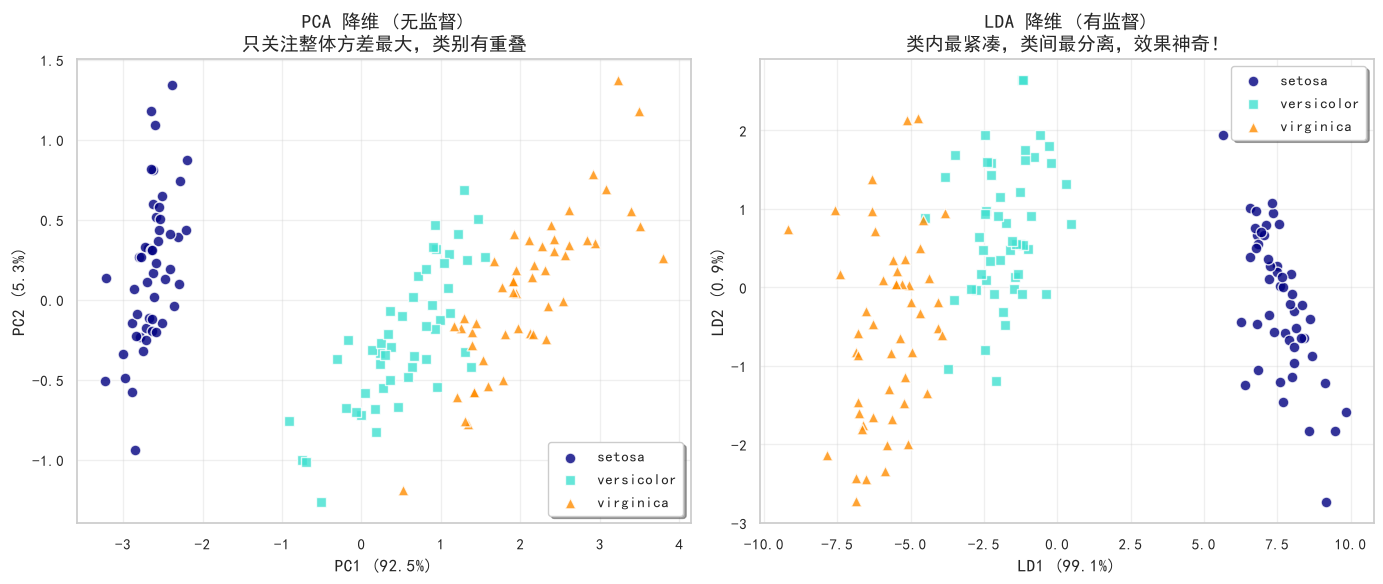

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

# 设置中文字体（防止图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 1. 加载鸢尾花数据集
# ============================================================
iris = datasets.load_iris()
X = iris.data          # 4维特征: 花萼长度、花萼宽度、花瓣长度、花瓣宽度
y = iris.target        # 3个类别: Setosa, Versicolour, Virginica
target_names = iris.target_names

# ============================================================
# 2. 降维处理：LDA vs PCA
# ============================================================
# 【LDA】有监督降维：利用标签 y，寻找最能区分不同类别的方向
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

# 【PCA】无监督降维：忽略标签 y，只寻找数据方差最大的方向
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 打印解释方差比例
print("=== 降维成分解释方差比例 ===")
print(f"PCA 解释方差比: {pca.explained_variance_ratio_.round(3)} (关注整体数据方差)")
print(f"LDA 解释方差比: {lda.explained_variance_ratio_.round(3)} (关注类间可分性)")

# ============================================================
# 3. 可视化对比
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['navy', 'turquoise', 'darkorange']
markers = ['o', 's', '^']

# ---------- 左图：PCA 降维结果 ----------
for color, marker, i, name in zip(colors, markers, [0, 1, 2], target_names):
    ax1.scatter(X_pca[y == i, 0], X_pca[y == i, 1], 
                alpha=0.8, color=color, marker=marker, 
                edgecolors='w', s=60, label=name)
ax1.set_title('PCA 降维 (无监督)\n只关注整体方差最大，类别有重叠', fontsize=14, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(loc='best', shadow=True)
ax1.grid(True, alpha=0.3)

# ---------- 右图：LDA 降维结果 ----------
for color, marker, i, name in zip(colors, markers, [0, 1, 2], target_names):
    ax2.scatter(X_lda[y == i, 0], X_lda[y == i, 1], 
                alpha=0.8, color=color, marker=marker, 
                edgecolors='w', s=60, label=name)
ax2.set_title('LDA 降维 (有监督)\n类内最紧凑，类间最分离，效果神奇！', fontsize=14, fontweight='bold')
ax2.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]*100:.1f}%)')
ax2.legend(loc='best', shadow=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

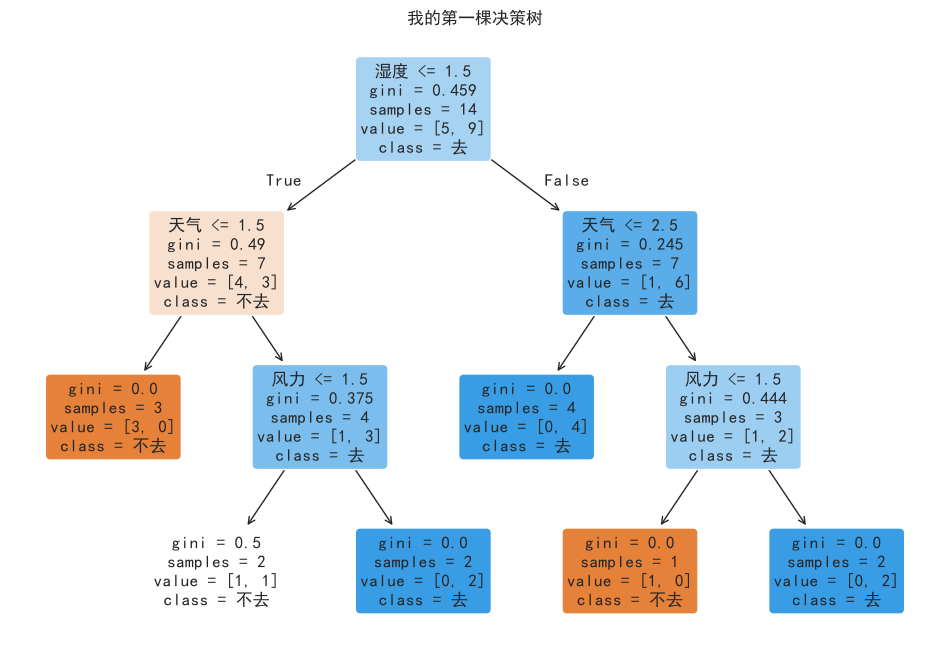


🤖 AI预测结果：今天适合去打网球！


c:\Users\yuhao.bian\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [4]:
# 1. 导入需要的工具包
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 【重要】设置中文字体，防止画图时中文变成乱码方块
# Windows电脑通常用 'SimHei' (黑体)，Mac电脑通常用 'Arial Unicode MS' 或 'PingFang SC'
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 2. 准备数据 (模拟14天的历史记录)
# ==========================================
# 为了让代码最简单，我们把文字转换成数字：
# 天气: 1=晴天, 2=阴天, 3=雨天
# 温度: 1=炎热, 2=适中, 3=寒冷
# 湿度: 1=高, 2=正常
# 风力: 1=强风, 2=微风
# 去打网球: 0=不去, 1=去

data = {
    '天气': [1, 1, 2, 3, 3, 3, 2, 1, 1, 3, 1, 2, 2, 3],
    '温度': [1, 1, 1, 2, 3, 3, 3, 2, 3, 2, 2, 2, 1, 2],
    '湿度': [1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1],
    '风力': [2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1],
    '去打网球': [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0] # 这是我们要预测的结果(标签)
}

# 把数据变成pandas表格格式 (就像Excel一样)
df = pd.DataFrame(data)

# 把“特征”(条件)和“标签”(结果)分开
X = df[['天气', '温度', '湿度', '风力']]  # AI需要看的条件
y = df['去打网球']                      # AI需要学习的答案

# ==========================================
# 3. 训练决策树模型 (让AI学习规律)
# ==========================================
# 创建一个决策树分类器，max_depth=3 表示树最多问3个问题，防止它学得太复杂
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 喂数据，让AI开始学习！(这是机器学习最核心的一句话)
clf.fit(X, y)

# ==========================================
# 4. 画出决策树 (看看AI学到了什么)
# ==========================================
plt.figure(figsize=(12, 8)) # 设置图片大小
plot_tree(clf, 
          feature_names=['天气', '温度', '湿度', '风力'], # 特征的名字
          class_names=['不去', '去'],                   # 结果的名字
          filled=True,                                  # 给方块填上颜色
          rounded=True,                                 # 方块圆角
          fontsize=12)
plt.title("我的第一棵决策树")
plt.show() # 显示图片

# ==========================================
# 5. 用AI做预测 (测试一下)
# ==========================================
# 假设今天是：1=晴天, 2=温度适中, 2=湿度正常, 1=强风
new_day = [[1, 2, 2, 1]] 
prediction = clf.predict(new_day)

if prediction[0] == 1:
    print("\n🤖 AI预测结果：今天适合去打网球！")
else:
    print("\n🤖 AI预测结果：今天不适合去打网球。")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ================= 1. 准备数据（把西瓜变成 PyTorch 认识的“张量”） =================
# 特征 X：[重量(斤), 甜度(1-10分)]
X_np = np.array([
    [2.0, 8.0], [3.0, 9.0], [2.5, 8.5],  # 好瓜
    [1.0, 2.0], [1.5, 3.0], [1.2, 2.5]   # 坏瓜
])
y_np = np.array([[1.0], [1.0], [1.0], [0.0], [0.0], [0.0]])

# 【新手注意】PyTorch 对数据类型要求很严，必须转换成 float32 格式的 Tensor（张量）
X_train = torch.tensor(X_np, dtype=torch.float32)
y_train = torch.tensor(y_np, dtype=torch.float32)


# ================= 2. 实例化神经网络（搭积木） =================
# 使用 nn.Sequential 按顺序堆叠网络层
model = nn.Sequential(
    # 第一层（隐藏层）：输入2个特征，输出4个神经元，使用 ReLU 激活
    nn.Linear(2, 4),
    nn.ReLU(),
    
    # 第二层（输出层）：输入4个，输出1个概率值，使用 Sigmoid 激活
    nn.Linear(4, 1),
    nn.Sigmoid()
)


# ================= 3. 设定学习规则（损失函数与优化器） =================
# 损失函数：二元交叉熵（专门用来算 0~1 概率的误差）
loss_fn = nn.BCELoss() 

# 优化器：Adam（西瓜书里的梯度下降法进阶版），lr=0.1 是学习率（下山的步长）
optimizer = optim.Adam(model.parameters(), lr=0.1) 


# ================= 4. 训练模型（见证 BP算法 奇迹的时刻！） =================
epochs = 100  # 把这批西瓜反复看 100 遍

for epoch in range(epochs):
    # 【第1步：前向传播】让模型猜一猜这批西瓜是好是坏
    predictions = model(X_train) 
    
    # 【第2步：计算误差】对比模型的猜测和真实答案，算出 Loss 值
    loss = loss_fn(predictions, y_train)
    
    # --- 下面这3行，就是西瓜书5.3节“误差逆传播(BP)”在代码里的真面目！ ---
    
    # 【第3步：清零梯度】把上一次的“下山方向”记录擦除，防止累加错误
    optimizer.zero_grad() 
    
    # 【第4步：反向传播】核心魔法！自动计算每个神经元对误差的“责任”(梯度)
    loss.backward()       
    
    # 【第5步：更新参数】根据算出的责任大小，调整神经元的权重(下山一步)
    optimizer.step()      

# 每隔 20 次打印一下误差，看看模型是不是越来越聪明（误差越来越小）
    if (epoch + 1) % 20 == 0:
        print(f"第 {epoch+1} 次学习，当前误差(Loss): {loss.item():.4f}")


# ================= 5. 预测新西瓜（考试） =================
# 来了一个新西瓜：重2.2斤，甜度8.5
new_melon = torch.tensor([[2.2, 8.5]], dtype=torch.float32)

# 评估模式下进行预测（关闭一些训练专用的随机机制）
model.eval() 
with torch.no_grad(): # 预测时不需要计算梯度，节省内存
    prediction = model(new_melon)

print(f"\n模型最终预测：这个西瓜是好瓜的概率为 {prediction.item()*100:.1f}%")

第 20 次学习，当前误差(Loss): 0.3747
第 40 次学习，当前误差(Loss): 0.0894
第 60 次学习，当前误差(Loss): 0.0352
第 80 次学习，当前误差(Loss): 0.0215
第 100 次学习，当前误差(Loss): 0.0153

模型最终预测：这个西瓜是好瓜的概率为 100.0%
